# 🫀 Heart Disease Prediction — Advanced Machine Learning Portfolio Task 1

---

| Field | Detail |
|---|---|
| **Module** | Advanced Machine Learning (COM 763) |
| **Assessment** | Portfolio Task 1 |
| **Dataset** | UCI Heart Disease Dataset (ID: 45) |
| **Objective** | Binary classification — predict presence of heart disease |
| **Deployment** | Streamlit Community Cloud |

---
##  Data Acquisition & Initial Inspection


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    cross_validate, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
sns.set_palette(PALETTE)

##  Data Loading
### from ucimlrepo import fetch_ucirepo
#### heart_disease = fetch_ucirepo(id=45)


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]
df_raw = pd.read_csv(url, header=None, names=col_names, na_values='?')
print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(10)

Dataset loaded: 303 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [3]:
# Schema & Data Types
print(df_raw.dtypes)
print()

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object



In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df_raw.describe().T.style.background_gradient(cmap='Blues').format("{:.2f}")

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,303.00,54.44,9.04,29.00,48.00,56.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,3.16,0.96,1.00,3.00,3.00,4.00,4.00
trestbps,303.00,131.69,17.60,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.69,51.78,126.00,211.00,241.00,275.00,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.99,0.99,0.00,0.00,1.00,2.00,2.00
thalach,303.00,149.61,22.88,71.00,133.50,153.00,166.00,202.00
exang,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [5]:
# ── Feature Dictionary ───────────────────────────────────────────────────────
feature_info = pd.DataFrame({
    'Feature':     ['age','sex','cp','trestbps','chol','fbs','restecg',
                    'thalach','exang','oldpeak','slope','ca','thal','num'],
    'Full Name':   ['Age','Sex','Chest Pain Type','Resting Blood Pressure',
                    'Serum Cholesterol','Fasting Blood Sugar',
                    'Resting ECG','Max Heart Rate Achieved',
                    'Exercise-Induced Angina','ST Depression',
                    'Slope of Peak ST','Num Major Vessels',
                    'Thalassemia','Diagnosis (Target)'],
    'Type':        ['Continuous','Binary','Categorical (1-4)','Continuous',
                    'Continuous','Binary','Categorical (0-2)','Continuous',
                    'Binary','Continuous','Categorical (1-3)','Ordinal (0-3)',
                    'Categorical','Target (0-4)'],
    'Values':      ['29–77','0=F, 1=M','1=typical, 2=atypical, 3=non-anginal, 4=asymptomatic',
                    'mm Hg','mg/dl','0: ≤120, 1: >120','0,1,2','bpm',
                    '0=No, 1=Yes','ST in mV (0–6.2)','1=up, 2=flat, 3=down',
                    '0–3','3=normal, 6=fixed, 7=reversible','0=no disease, 1-4=disease']
})

feature_info.style.set_table_styles([
    {'selector': 'th', 'props': [('background', '#1565C0'), ('color', 'white'), ('font-size', '13px')]},
    {'selector': 'td', 'props': [('font-size', '12px')]}
]).hide(axis='index')

Feature,Full Name,Type,Values
age,Age,Continuous,29–77
sex,Sex,Binary,"0=F, 1=M"
cp,Chest Pain Type,Categorical (1-4),"1=typical, 2=atypical, 3=non-anginal, 4=asymptomatic"
trestbps,Resting Blood Pressure,Continuous,mm Hg
chol,Serum Cholesterol,Continuous,mg/dl
fbs,Fasting Blood Sugar,Binary,"0: ≤120, 1: >120"
restecg,Resting ECG,Categorical (0-2),"0,1,2"
thalach,Max Heart Rate Achieved,Continuous,bpm
exang,Exercise-Induced Angina,Binary,"0=No, 1=Yes"
oldpeak,ST Depression,Continuous,ST in mV (0–6.2)


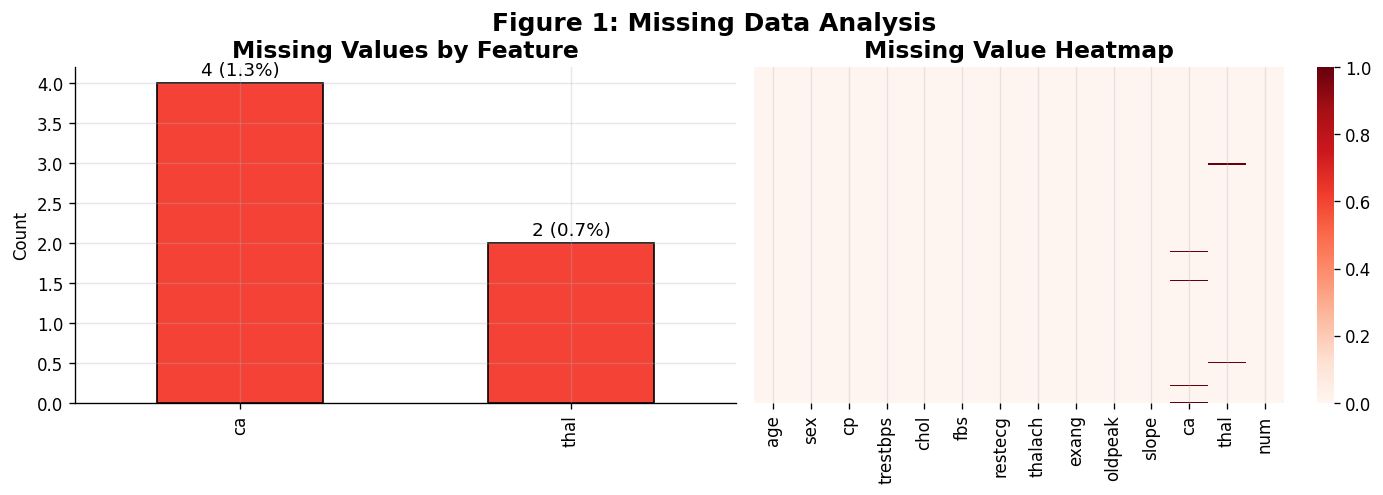

In [6]:
# ── Missing Values Analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
missing_df['Missing Count'].plot(kind='bar', ax=axes[0], color='#F44336', edgecolor='black')
axes[0].set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
for i, (v, pct) in enumerate(zip(missing_df['Missing Count'], missing_df['Missing %'])):
    axes[0].text(i, v + 0.05, f'{v} ({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=True, cmap='Reds',
            ax=axes[1])
axes[1].set_title('Missing Value Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.suptitle('Figure 1: Missing Data Analysis', y=1.02, fontsize=15, fontweight='bold')
plt.show()

---
## 3. Exploratory Data Analysis

EDA is conducted across four dimensions:
1. **Target distribution** — class balance check  
2. **Univariate analysis** — distribution of each feature  
3. **Bivariate analysis** — feature vs target relationships  
4. **Correlation analysis** — multicollinearity check


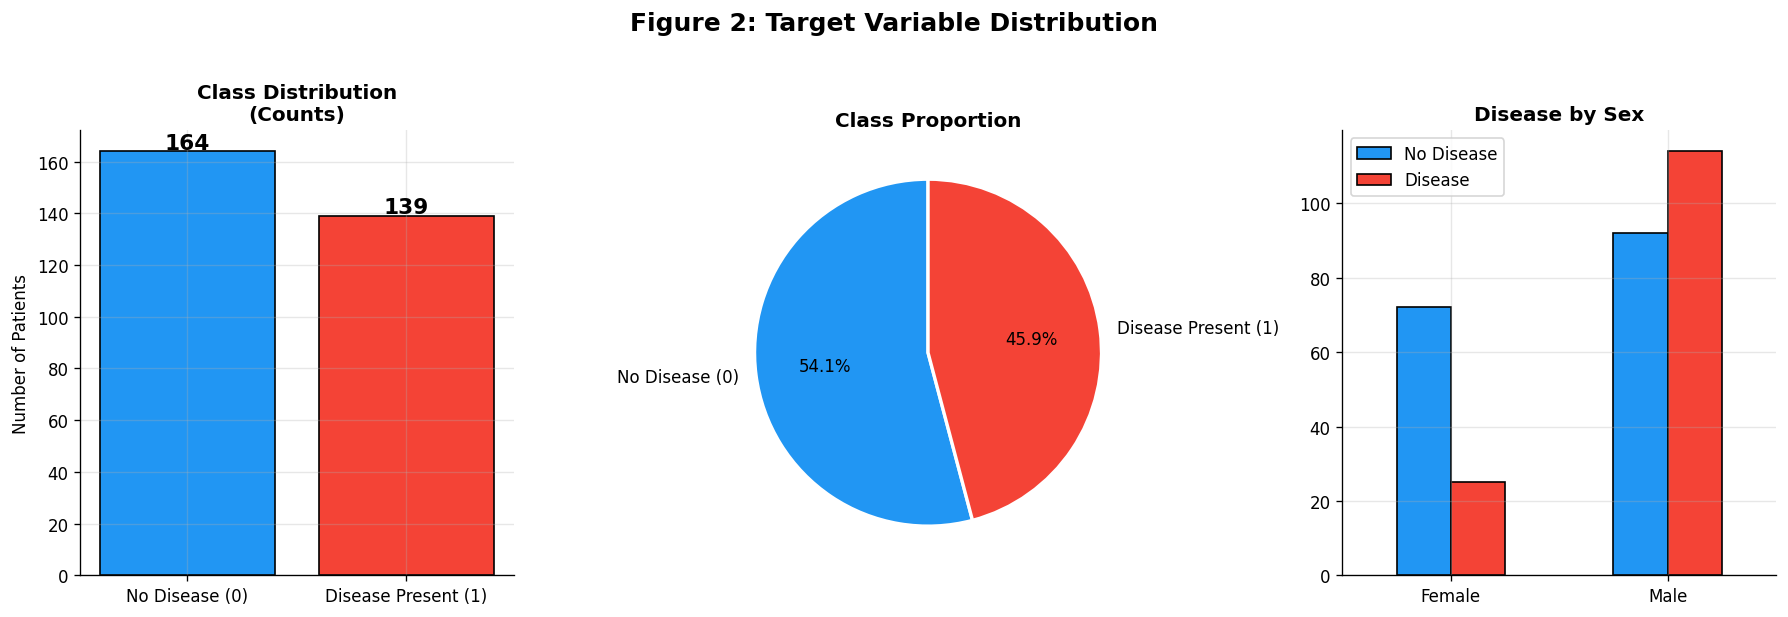

In [7]:
# Target Variable Analysis
df = df_raw.copy()
df['target'] = (df['num'] > 0).astype(int)
df.drop(columns='num', inplace=True)
target_counts = df['target'].value_counts()
target_labels = ['No Disease (0)', 'Disease Present (1)']
colors = ['#2196F3', '#F44336']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(target_labels, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution\n(Counts)', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=13, fontweight='bold')
axes[1].pie(target_counts.values, labels=target_labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.index = ['Female', 'Male']
sex_target.columns = ['No Disease', 'Disease']
sex_target.plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('Disease by Sex', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend()
plt.suptitle('Figure 2: Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

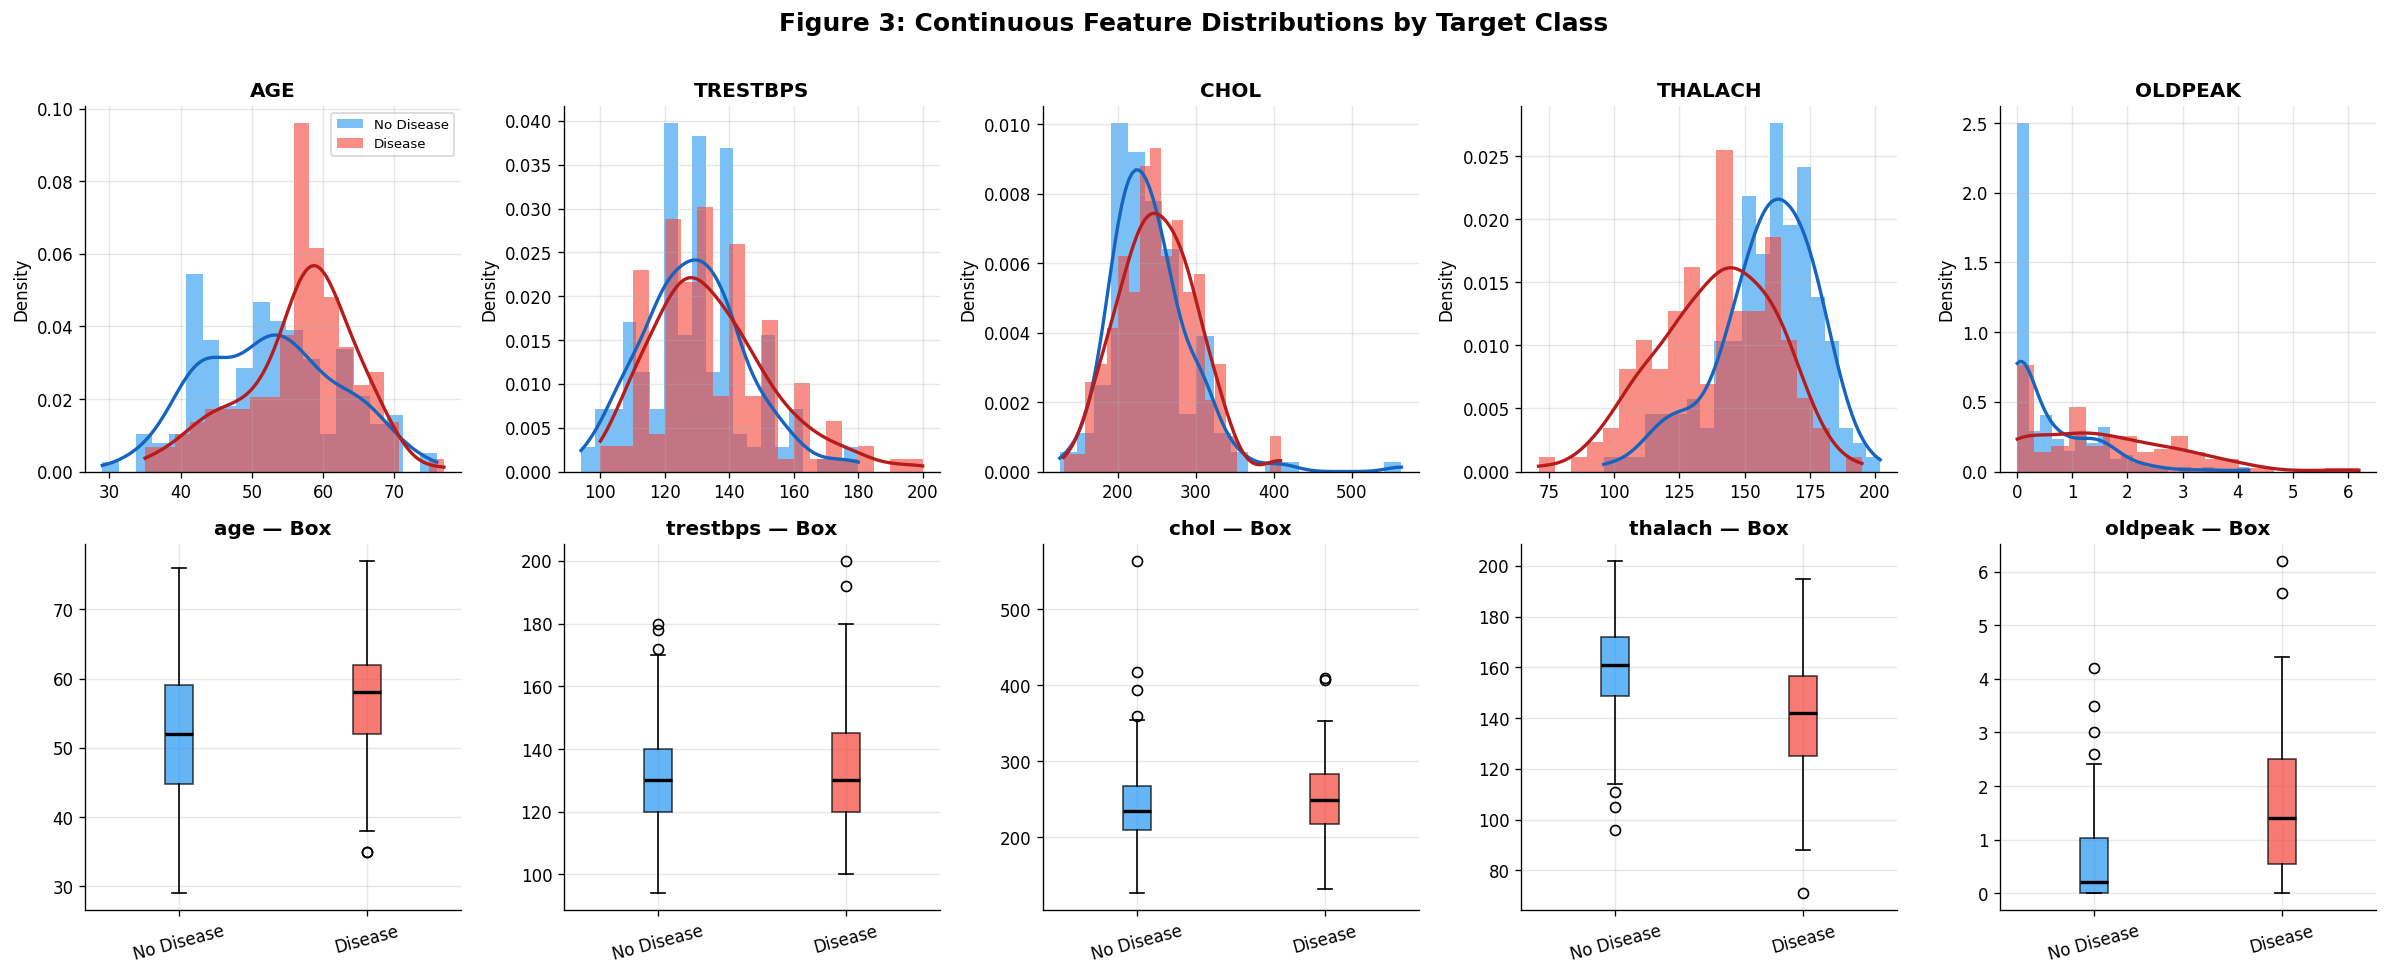

In [8]:
#  Univariate Distributions
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, feat in enumerate(continuous_features):
    data_no = df[df['target'] == 0][feat].dropna()
    data_yes = df[df['target'] == 1][feat].dropna()
    axes[0, i].hist(data_no, bins=20, alpha=0.6, color='#2196F3', label='No Disease', density=True)
    axes[0, i].hist(data_yes, bins=20, alpha=0.6, color='#F44336', label='Disease', density=True)
    from scipy.stats import gaussian_kde
    for data, c in [(data_no, '#1565C0'), (data_yes, '#B71C1C')]:
        kde = gaussian_kde(data.dropna())
        x_range = np.linspace(data.min(), data.max(), 100)
        axes[0, i].plot(x_range, kde(x_range), color=c, linewidth=2)
    axes[0, i].set_title(feat.upper(), fontweight='bold')
    if i == 0:
        axes[0, i].legend(fontsize=8)
    axes[0, i].set_ylabel('Density')
    bp_data = [data_no, data_yes]
    bp = axes[1, i].boxplot(bp_data, patch_artist=True,
                             labels=['No Disease', 'Disease'],
                             medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], ['#2196F3', '#F44336']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1, i].set_title(f'{feat} — Box', fontweight='bold')
    axes[1, i].tick_params(axis='x', rotation=15)
plt.suptitle('Figure 3: Continuous Feature Distributions by Target Class',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

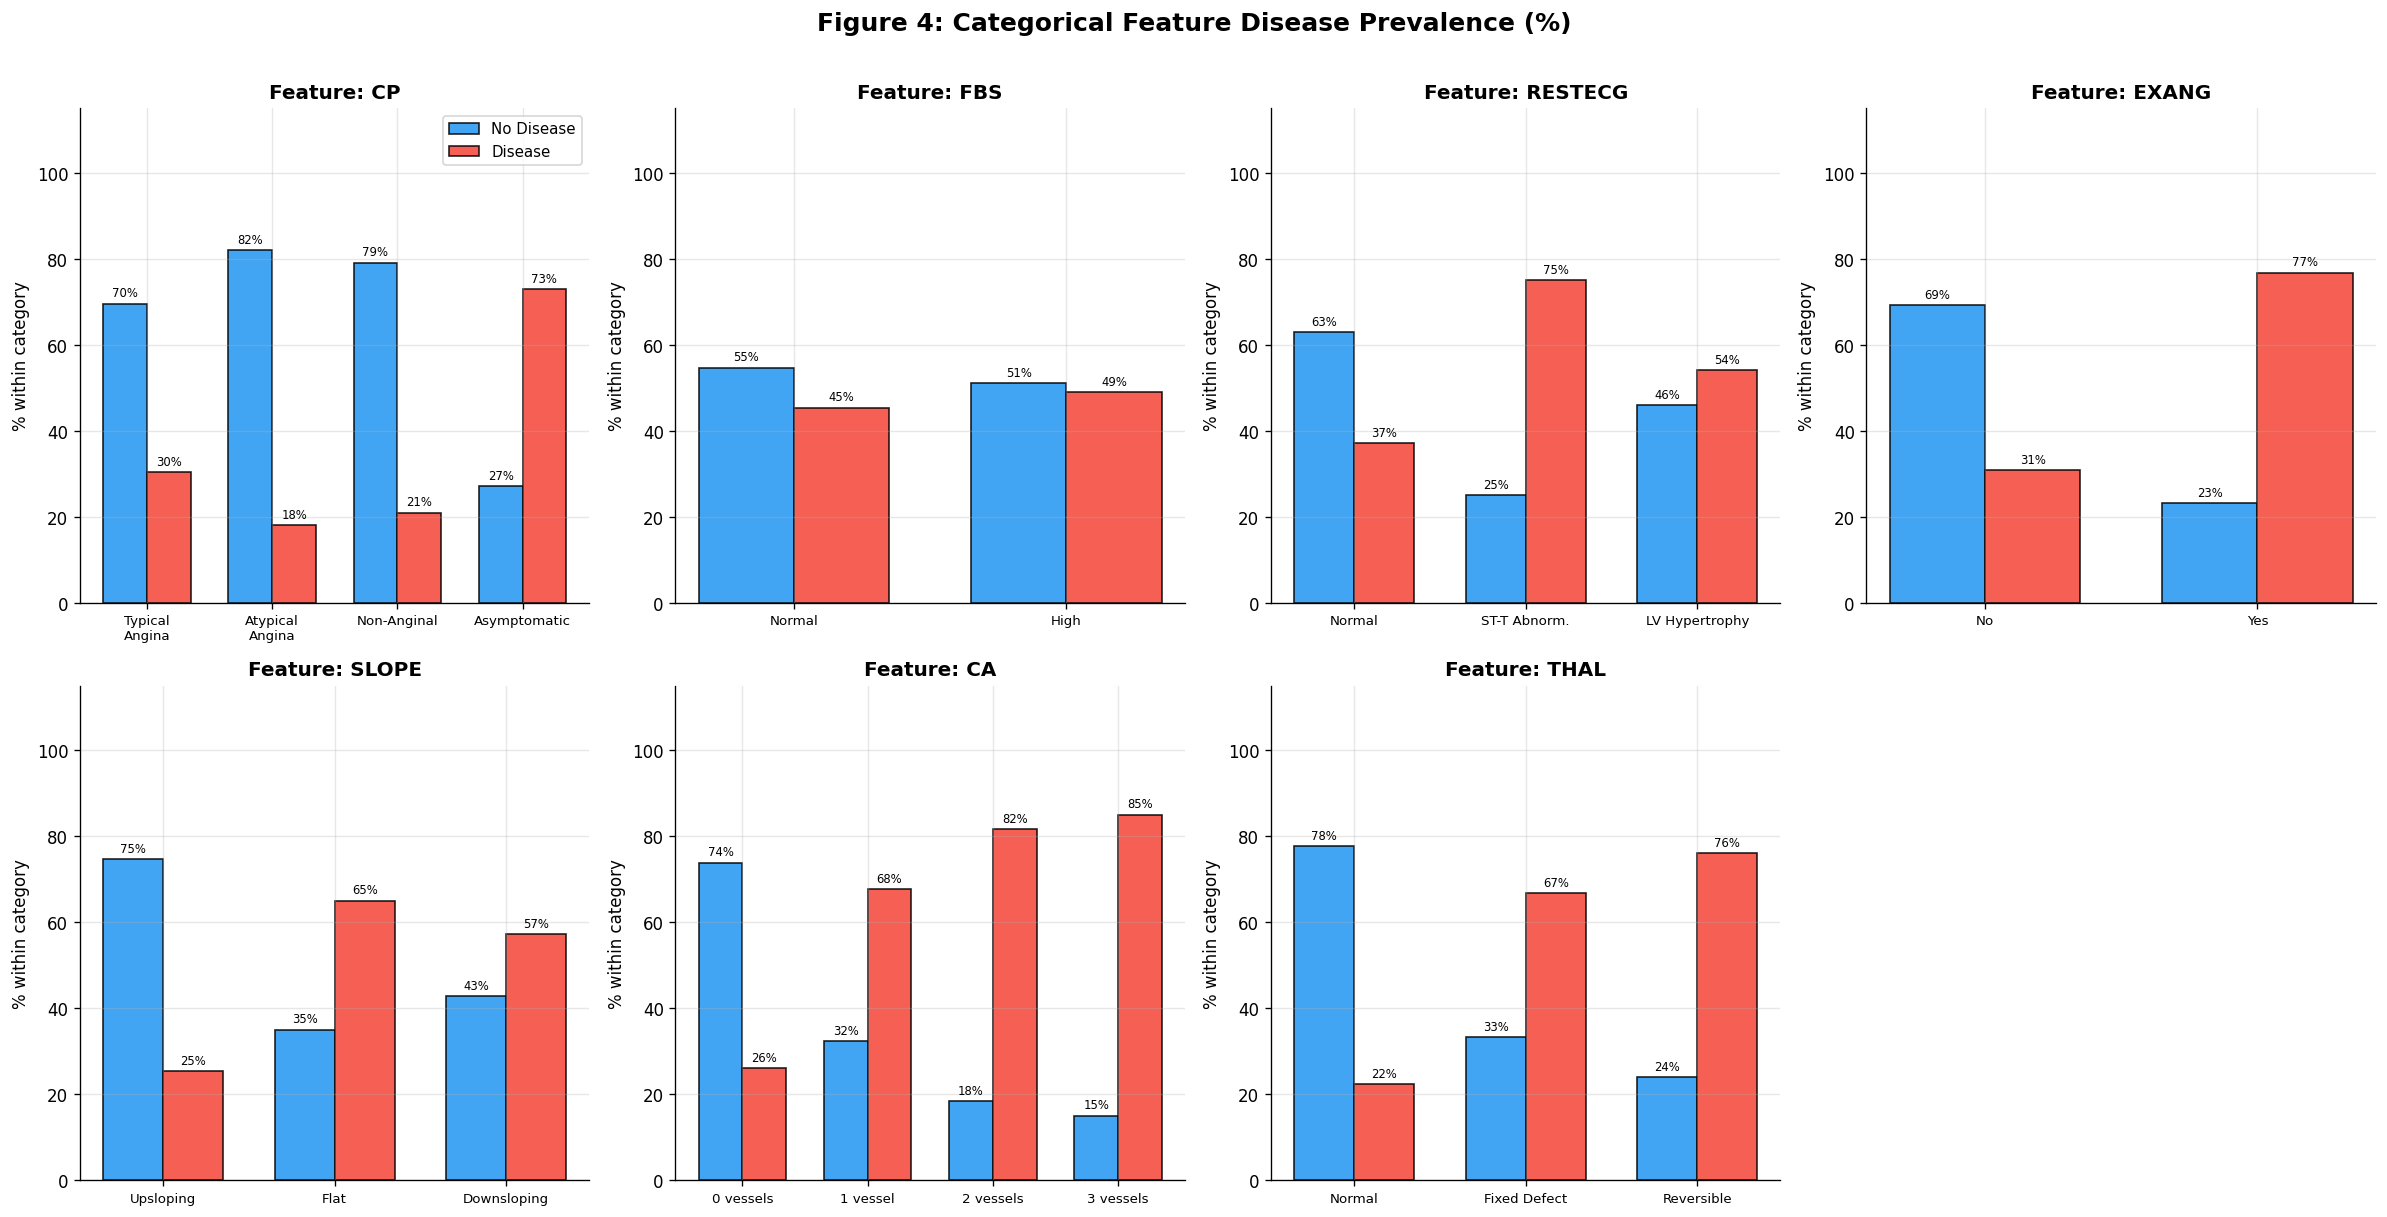

In [9]:
# Categorical Feature Analysis
cat_features = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'cp':      {1: 'Typical\nAngina', 2: 'Atypical\nAngina', 3: 'Non-Anginal', 4: 'Asymptomatic'},
    'exang':   {0: 'No', 1: 'Yes'},
    'fbs':     {0: 'Normal', 1: 'High'},
    'slope':   {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnorm.', 2: 'LV Hypertrophy'},
    'thal':    {3: 'Normal', 6: 'Fixed Defect', 7: 'Reversible'},
    'ca':      {0: '0 vessels', 1: '1 vessel', 2: '2 vessels', 3: '3 vessels'}
}
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, feat in enumerate(cat_features):
    df_temp = df[[feat, 'target']].dropna()
    pivot = df_temp.groupby([feat, 'target']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    x = np.arange(len(pivot_pct))
    width = 0.35
    b1 = axes[i].bar(x - width/2, pivot_pct.get(0, 0), width, label='No Disease',
                      color='#2196F3', edgecolor='black', alpha=0.85)
    b2 = axes[i].bar(x + width/2, pivot_pct.get(1, 0), width, label='Disease',
                      color='#F44336', edgecolor='black', alpha=0.85)
    tick_labels = [cat_labels.get(feat, {}).get(k, str(k)) for k in pivot_pct.index]
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(tick_labels, fontsize=8)
    axes[i].set_title(f'Feature: {feat.upper()}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('% within category')
    axes[i].set_ylim(0, 115)
    if i == 0:
        axes[i].legend(fontsize=9)
    for bar in [b1, b2]:
        for rect in bar:
            h = rect.get_height()
            if h > 5:
                axes[i].text(rect.get_x() + rect.get_width()/2., h + 1,
                              f'{h:.0f}%', ha='center', va='bottom', fontsize=7)
axes[-1].set_visible(False)
plt.suptitle('Figure 4: Categorical Feature Disease Prevalence (%)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


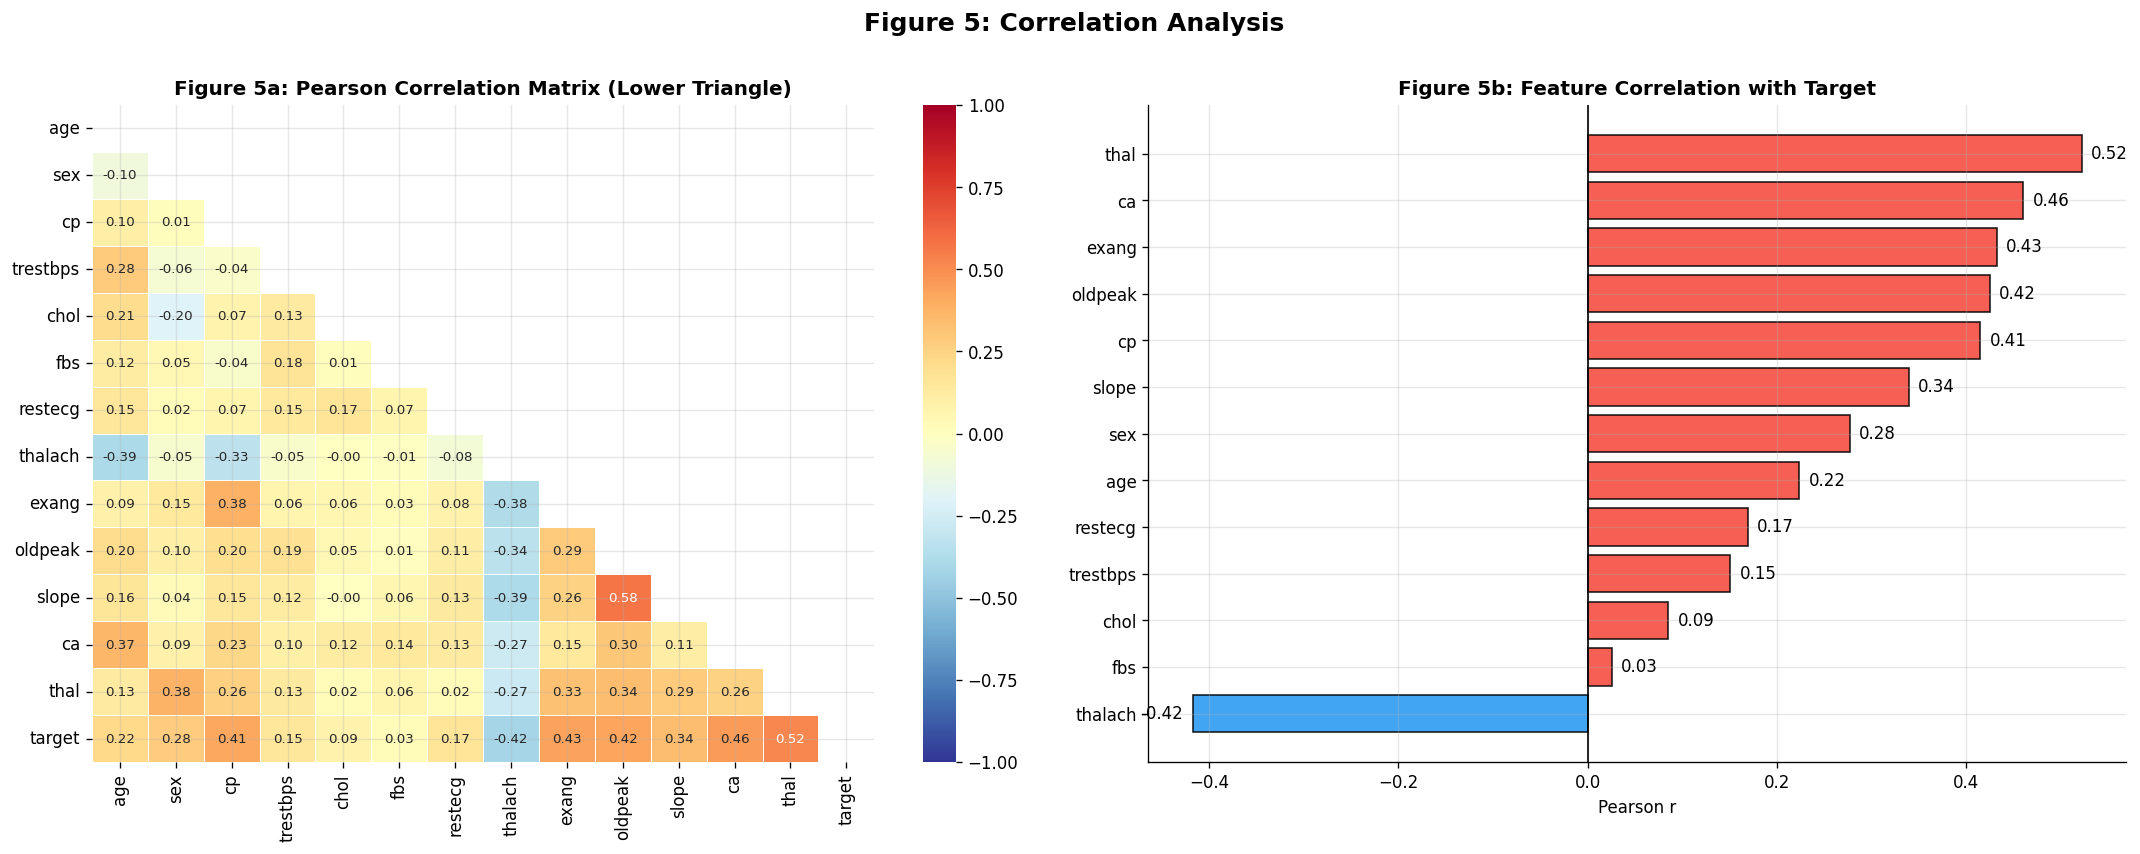

In [10]:
#  Correlation Analysis ──────────────────────────────────────────────────
df_corr = df.copy()
df_corr_filled = df_corr.fillna(df_corr.median(numeric_only=True))
corr_matrix = df_corr_filled.corr()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 8}, linewidths=0.5)
axes[0].set_title('Figure 5a: Pearson Correlation Matrix (Lower Triangle)',
                  fontweight='bold', fontsize=12)
target_corr = corr_matrix['target'].drop('target').sort_values()
colors_bar = ['#F44336' if v > 0 else '#2196F3' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Figure 5b: Feature Correlation with Target',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Pearson r')
for i, (v, label) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                  f'{v:.2f}', va='center', ha=('left' if v >= 0 else 'right'), fontsize=10)
plt.suptitle('Figure 5: Correlation Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
print("Top positive correlates with disease:")
print(target_corr.tail(5).to_string())
print("\nTop negative correlates:")
print(target_corr.head(5).to_string())

Top positive correlates with disease:
cp         0.414446
oldpeak    0.424510
exang      0.431894
ca         0.460033
thal       0.522057

Top negative correlates:
thalach    -0.417167
fbs         0.025264
chol        0.085164
trestbps    0.150825
restecg     0.169202


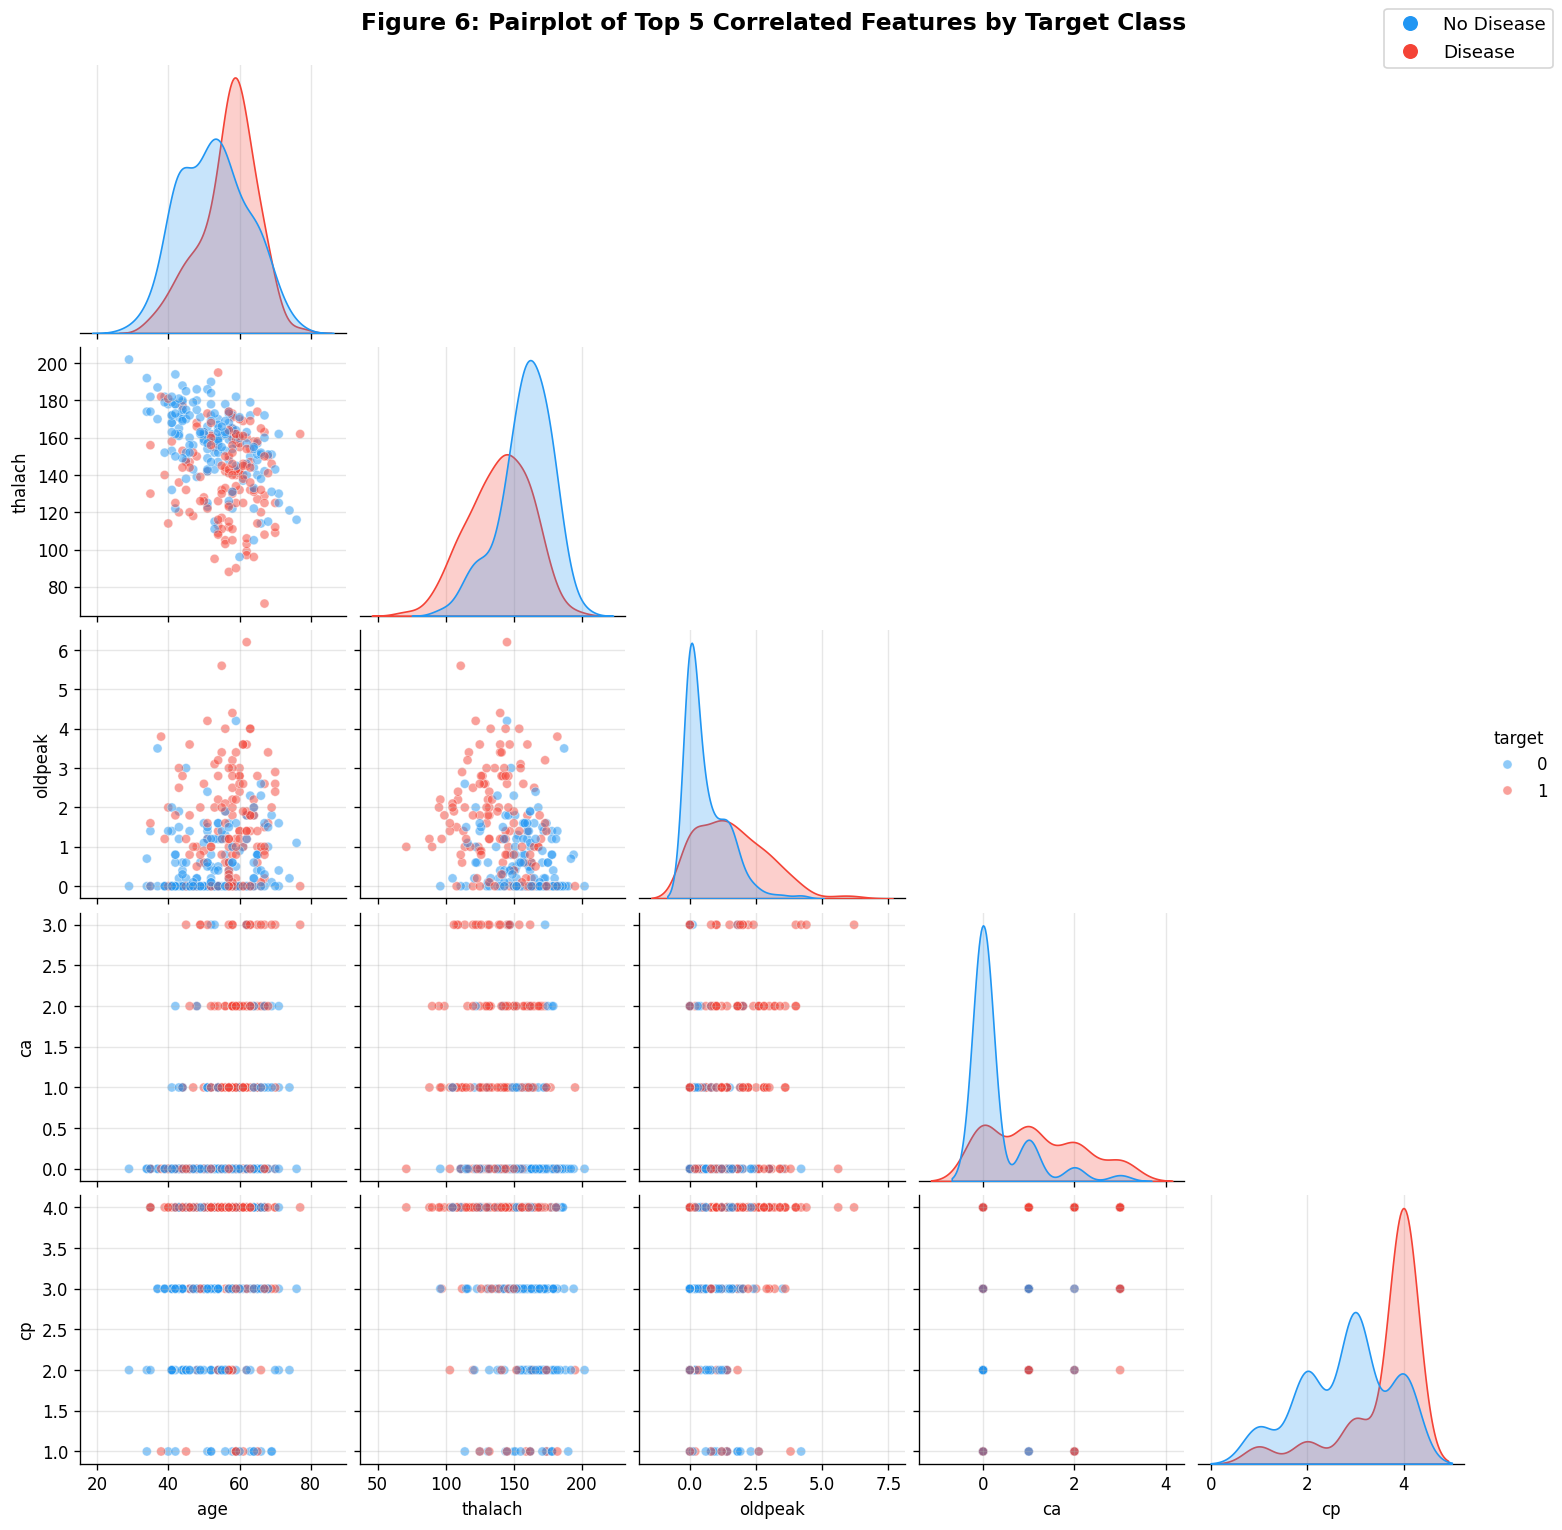

In [12]:
# Pairplot
top_features = ['age', 'thalach', 'oldpeak', 'ca', 'cp', 'target']
df_pair = df[top_features].dropna()
g = sns.pairplot(df_pair, hue='target', palette={0: '#2196F3', 1: '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 corner=True)
g.fig.suptitle('Figure 6: Pairplot of Top 5 Correlated Features by Target Class',
               y=1.02, fontsize=14, fontweight='bold')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='No Disease'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=10, label='Disease')]
g.fig.legend(handles=handles, loc='upper right', fontsize=11)
plt.show()

---
##  Data Pipeline & Feature Engineering




In [13]:
# Preprocessing Steps
df_clean = df.copy()
for col in ['ca', 'thal']:
    median_val = df_clean[col].median()
    n_missing = df_clean[col].isna().sum()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"   '{col}': {n_missing} missing → imputed with median = {median_val}")
print(f"   Remaining NaNs: {df_clean.isna().sum().sum()}")
print("\nCapping outliers (IQR × 1.5)...")
continuous_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
outlier_report = []
for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    outlier_report.append({'Feature': col, 'Lower Bound': f'{lower:.2f}',
                            'Upper Bound': f'{upper:.2f}', 'Outliers Capped': n_out})
outlier_df = pd.DataFrame(outlier_report)
print(outlier_df.to_string(index=False))
print("\nCleaning complete. Shape:", df_clean.shape)

   'ca': 4 missing → imputed with median = 0.0
   'thal': 2 missing → imputed with median = 3.0
   Remaining NaNs: 0

Capping outliers (IQR × 1.5)...
 Feature Lower Bound Upper Bound  Outliers Capped
trestbps       90.00      170.00                9
    chol      115.00      371.00                5
 thalach       84.75      214.75                1
 oldpeak       -2.40        4.00                5

Cleaning complete. Shape: (303, 14)


In [14]:
# Feature Engineering
# Age group (clinically meaningful bins)
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0, 40, 55, 65, 100],
                                labels=[0, 1, 2, 3]).astype(int)
# High cholesterol flag
df_clean['high_chol'] = (df_clean['chol'] > 200).astype(int)
# Tachycardia flag
df_clean['tachycardia'] = (df_clean['thalach'] > 100).astype(int)
# Risk score composite
df_clean['risk_score'] = (df_clean['age'] / df_clean['age'].max() * 0.3 +
                           df_clean['oldpeak'] / df_clean['oldpeak'].max() * 0.3 +
                           df_clean['ca'] / 3 * 0.4)
print(f"\nDataset shape after feature engineering: {df_clean.shape}")
df_clean.head(3)


Dataset shape after feature engineering: (303, 18)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,high_chol,tachycardia,risk_score
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,2,1,1,0.417955
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,3,1,1,0.773539
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,3,1,1,0.722706


In [15]:
#  Train/Test Split
FEATURES = [c for c in df_clean.columns if c != 'target']
TARGET = 'target'
X = df_clean[FEATURES]
y = df_clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Feature count: {X_train.shape[1]}")
print()
print(f"Training  class balance — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()} "
      f"({(y_train==1).mean()*100:.1f}% positive)")
print(f"Test      class balance — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()} "
      f"({(y_test==1).mean()*100:.1f}% positive)")

Training set : 242 samples
Test set     : 61 samples
Feature count: 17

Training  class balance — 0: 131, 1: 111 (45.9% positive)
Test      class balance — 0: 33,  1: 28 (45.9% positive)


In [16]:
#  Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=FEATURES, index=X_test.index
)

---
## Model Implementation & Debugging

Five algorithms are selected to cover a range of model families:

| Model | Family | Key Hyperparameters | Rationale |
|---|---|---|---|
| Logistic Regression | Linear | C, solver | Interpretable baseline |
| Decision Tree | Tree | max_depth, min_samples_split | Non-linear, visualisable |
| Random Forest | Ensemble (Bagging) | n_estimators, max_depth | Robust, feature importance |
| Gradient Boosting | Ensemble (Boosting) | learning_rate, n_estimators | High performance |
| SVM | Kernel | C, kernel, gamma | Effective in small datasets |


In [17]:
#  Baseline Model Training
models_baseline = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
print("=" * 65)
for name, model in models_baseline.items():
    scores = cross_validate(
        model, X_train_scaled, y_train, cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc', 'recall', 'precision'],
        return_train_score=True
    )
    cv_results[name] = scores
    print(f"{name:25s} | CV F1: {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f} "
          f"| AUC: {scores['test_roc_auc'].mean():.3f}")

Logistic Regression       | CV F1: 0.799 ± 0.019 | AUC: 0.897
Decision Tree             | CV F1: 0.661 ± 0.043 | AUC: 0.682
Random Forest             | CV F1: 0.803 ± 0.015 | AUC: 0.892
Gradient Boosting         | CV F1: 0.747 ± 0.025 | AUC: 0.851
SVM                       | CV F1: 0.802 ± 0.032 | AUC: 0.882


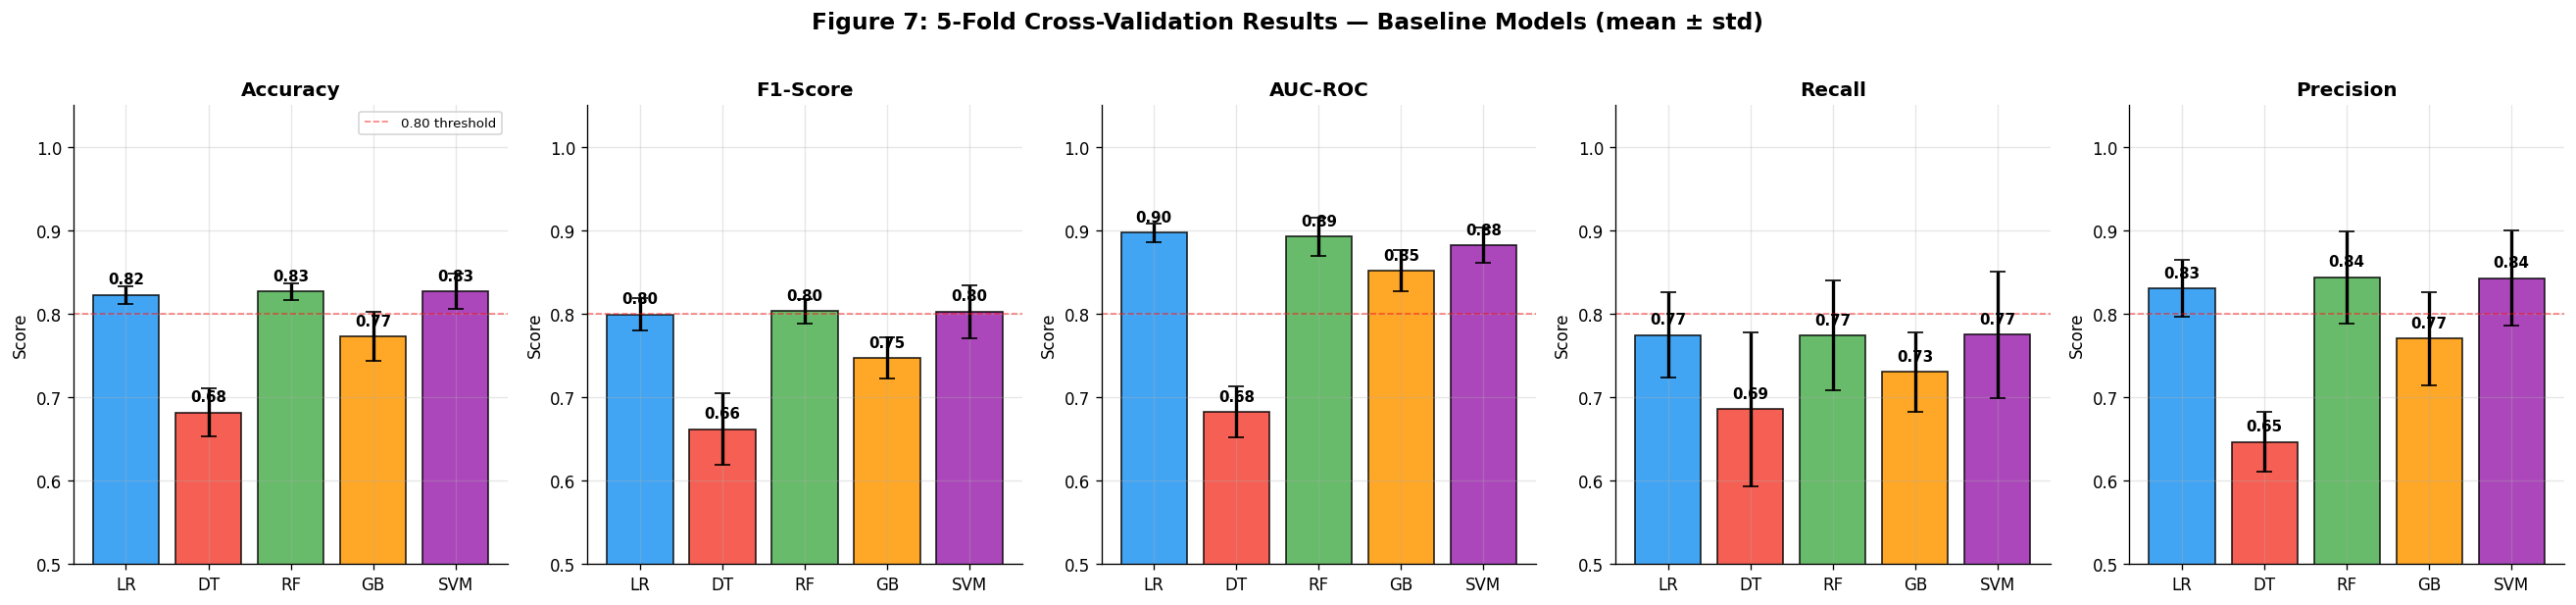

In [18]:
# CV Results Visualisation
metrics = ['test_accuracy', 'test_f1', 'test_roc_auc', 'test_recall', 'test_precision']
metric_names = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Recall', 'Precision']
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, metric, mname in zip(axes, metrics, metric_names):
    means = [cv_results[m][metric].mean() for m in models_baseline]
    stds  = [cv_results[m][metric].std()  for m in models_baseline]
    model_names_short = ['LR', 'DT', 'RF', 'GB', 'SVM']
    bars = ax.bar(model_names_short, means, yerr=stds, capsize=5,
                   color=PALETTE, edgecolor='black', alpha=0.85,
                   error_kw={'elinewidth': 2, 'ecolor': 'black'})
    ax.set_title(mname, fontweight='bold', fontsize=12)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Score')
    ax.axhline(0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='0.80 threshold')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{mean:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=8)
plt.suptitle('Figure 7: 5-Fold Cross-Validation Results — Baseline Models (mean ± std)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Overfitting Diagnosis
print("OVERFITTING ANALYSIS — Train vs CV F1 Gap")
print("=" * 55)
overfit_data = []
for name in models_baseline:
    train_f1 = cv_results[name]['train_f1'].mean()
    test_f1  = cv_results[name]['test_f1'].mean()
    gap = train_f1 - test_f1
    flag = 'OVERFIT' if gap > 0.10 else 'OK'
    overfit_data.append({'Model': name, 'Train F1': f'{train_f1:.3f}',
                          'CV F1': f'{test_f1:.3f}', 'Gap': f'{gap:.3f}', 'Status': flag})
    print(f"{name:25s} | Train: {train_f1:.3f} | CV: {test_f1:.3f} | Gap: {gap:.3f} {flag}")

OVERFITTING ANALYSIS — Train vs CV F1 Gap
Logistic Regression       | Train: 0.835 | CV: 0.799 | Gap: 0.036 OK
Decision Tree             | Train: 1.000 | CV: 0.661 | Gap: 0.339 OVERFIT
Random Forest             | Train: 1.000 | CV: 0.803 | Gap: 0.197 OVERFIT
Gradient Boosting         | Train: 1.000 | CV: 0.747 | Gap: 0.253 OVERFIT
SVM                       | Train: 0.887 | CV: 0.802 | Gap: 0.084 OK


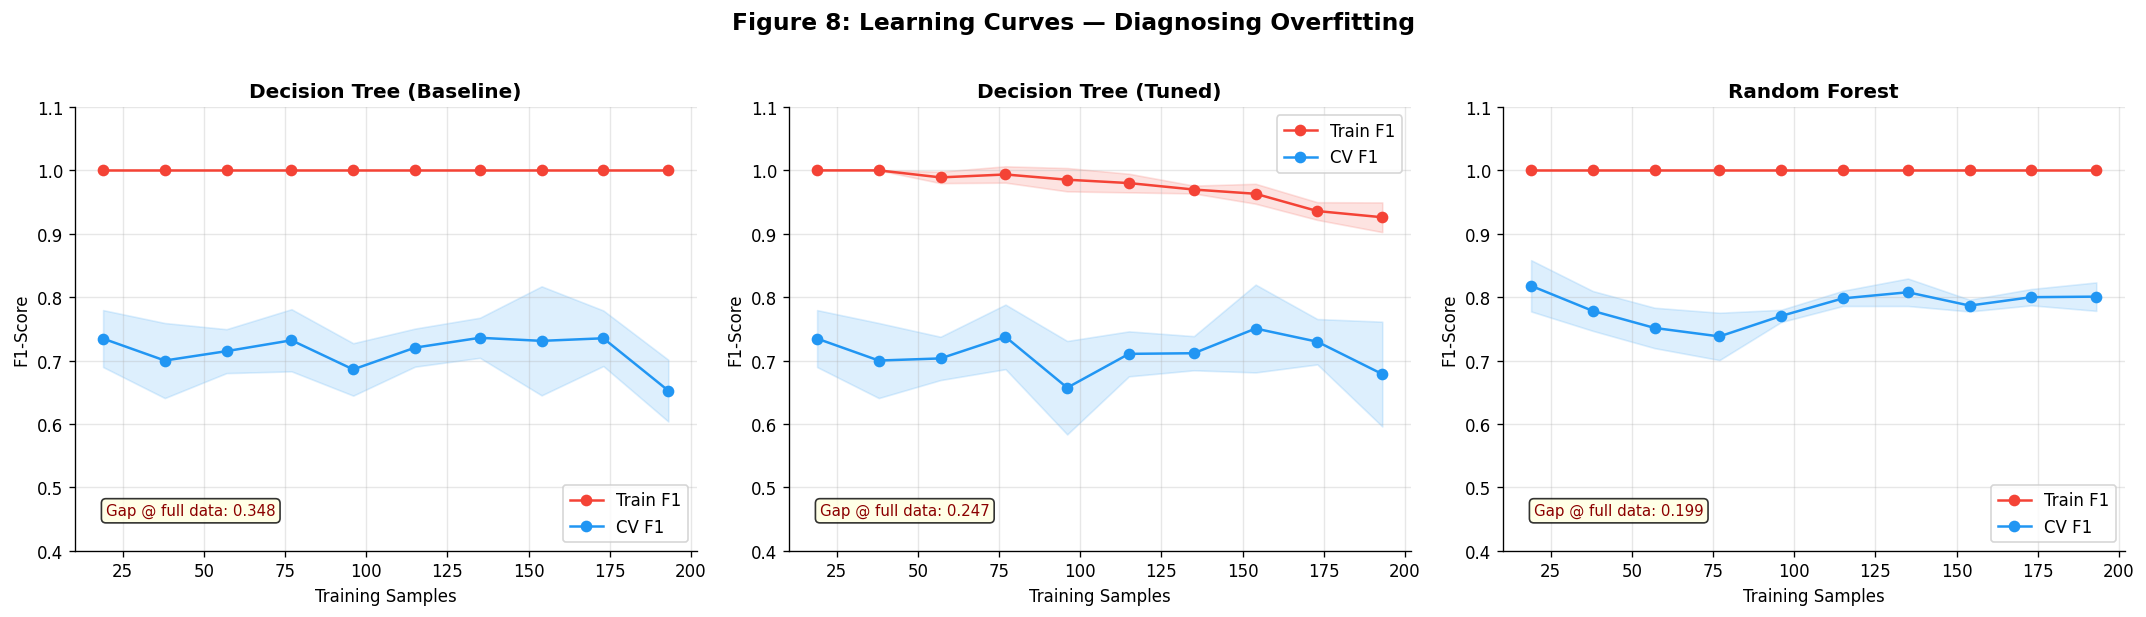

In [20]:
# Learning Curves — Debugging Overfitting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lc_models = {
    'Decision Tree (Baseline)': DecisionTreeClassifier(random_state=42),
    'Decision Tree (Tuned)':    DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42)
}
for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=cv, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    ax.plot(train_sizes, train_mean, 'o-', color='#F44336', label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#F44336')
    ax.plot(train_sizes, val_mean, 'o-', color='#2196F3', label='CV F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#2196F3')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0.4, 1.1)
    ax.legend()
    gap = train_mean[-1] - val_mean[-1]
    ax.text(0.05, 0.08, f'Gap @ full data: {gap:.3f}', transform=ax.transAxes,
             fontsize=9, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.suptitle('Figure 8: Learning Curves — Diagnosing Overfitting',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Hyperparameter Tuning (GridSearchCV
print("Hyperparameter Tuning with GridSearchCV (5-Fold CV, scoring='f1')")
print("=" * 70)
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
}
base_estimators = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}
tuned_models = {}
tuning_results = []
for name, estimator in base_estimators.items():
    gs = GridSearchCV(
        estimator, param_grids[name],
        cv=cv, scoring='f1', n_jobs=-1, refit=True
    )
    gs.fit(X_train_scaled, y_train)
    tuned_models[name] = gs.best_estimator_
    tuning_results.append({
        'Model': name,
        'Best CV F1': f"{gs.best_score_:.3f}",
        'Best Params': str(gs.best_params_)
    })
    print(f"{name:25s} → Best CV F1: {gs.best_score_:.3f} | Params: {gs.best_params_}")
tuned_models['Decision Tree'] = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)
tuned_models['Decision Tree'].fit(X_train_scaled, y_train)

Hyperparameter Tuning with GridSearchCV (5-Fold CV, scoring='f1')
Logistic Regression       → Best CV F1: 0.813 | Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Random Forest             → Best CV F1: 0.804 | Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Gradient Boosting         → Best CV F1: 0.804 | Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
SVM                       → Best CV F1: 0.804 | Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)

---
## Experimental Evaluation & Model Selection


In [22]:
#  Hold-Out Test Set Evaluation
print("TEST SET EVALUATION — Tuned Models")
print("=" * 75)
results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })
results_df = pd.DataFrame(results).set_index('Model').round(3)
styled = results_df.style.highlight_max(
    axis=0, color='#C8E6C9'
).format("{:.3f}").set_caption("Table 1: Test Set Evaluation Metrics — All Tuned Models")
print(results_df.to_string())
styled

TEST SET EVALUATION — Tuned Models
                     Accuracy  Precision  Recall     F1  AUC-ROC
Model                                                           
Logistic Regression     0.869      0.812   0.929  0.867    0.958
Random Forest           0.885      0.839   0.929  0.881    0.957
Gradient Boosting       0.852      0.788   0.929  0.852    0.956
SVM                     0.852      0.828   0.857  0.842    0.934
Decision Tree           0.754      0.686   0.857  0.762    0.817


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.869,0.812,0.929,0.867,0.958
Random Forest,0.885,0.839,0.929,0.881,0.957
Gradient Boosting,0.852,0.788,0.929,0.852,0.956
SVM,0.852,0.828,0.857,0.842,0.934
Decision Tree,0.754,0.686,0.857,0.762,0.817


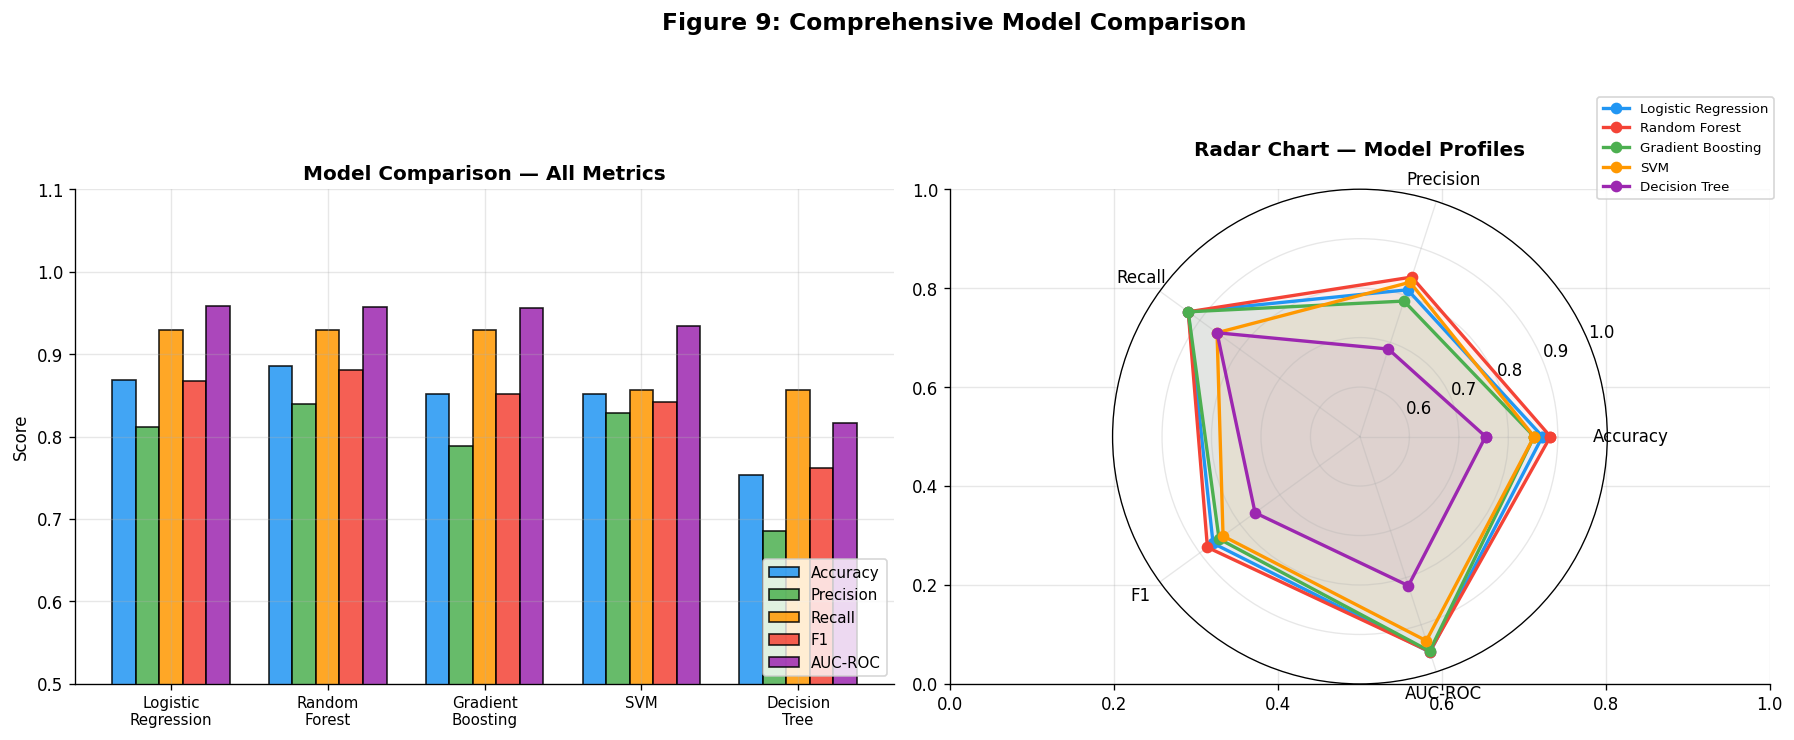

In [23]:
# Comparative Metrics Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
results_plot = results_df.reset_index()
x = np.arange(len(results_plot))
width = 0.15
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
metric_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
for j, (metric, color) in enumerate(zip(metrics_to_plot, metric_colors)):
    axes[0].bar(x + j * width, results_plot[metric], width,
                label=metric, color=color, edgecolor='black', alpha=0.85)
axes[0].set_xticks(x + 2 * width)
axes[0].set_xticklabels([r.replace(' ', '\n') for r in results_plot['Model']], fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.1)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_title('Model Comparison — All Metrics', fontweight='bold')
categories = metrics_to_plot
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
ax_radar = plt.subplot(1, 2, 2, polar=True)
radar_colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
for i, (_, row) in enumerate(results_plot.iterrows()):
    values = [row[m] for m in categories]
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2,
                   color=radar_colors[i], label=row['Model'])
    ax_radar.fill(angles, values, alpha=0.07, color=radar_colors[i])
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=10)
ax_radar.set_ylim(0.5, 1.0)
ax_radar.set_title('Radar Chart — Model Profiles', fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.2), fontsize=8)
plt.suptitle('Figure 9: Comprehensive Model Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

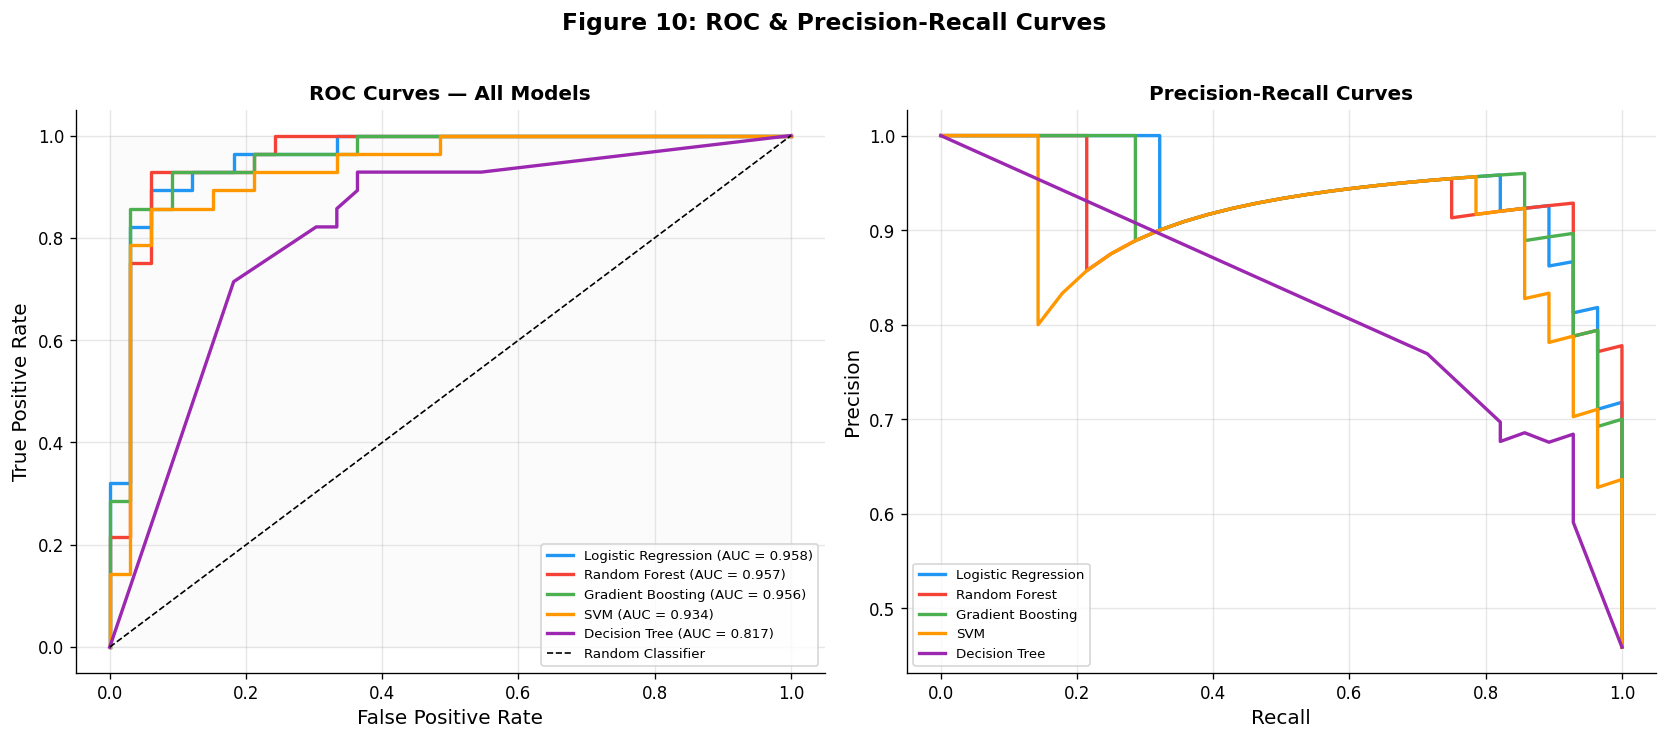

In [24]:
#  ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (name, model) in enumerate(tuned_models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, linewidth=2, color=PALETTE[i],
                  label=f'{name} (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].fill_between([0, 1], [0, 0], [1, 1], alpha=0.03, color='grey')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
for i, (name, model) in enumerate(tuned_models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, linewidth=2, color=PALETTE[i], label=name)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower left')
plt.suptitle('Figure 10: ROC & Precision-Recall Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

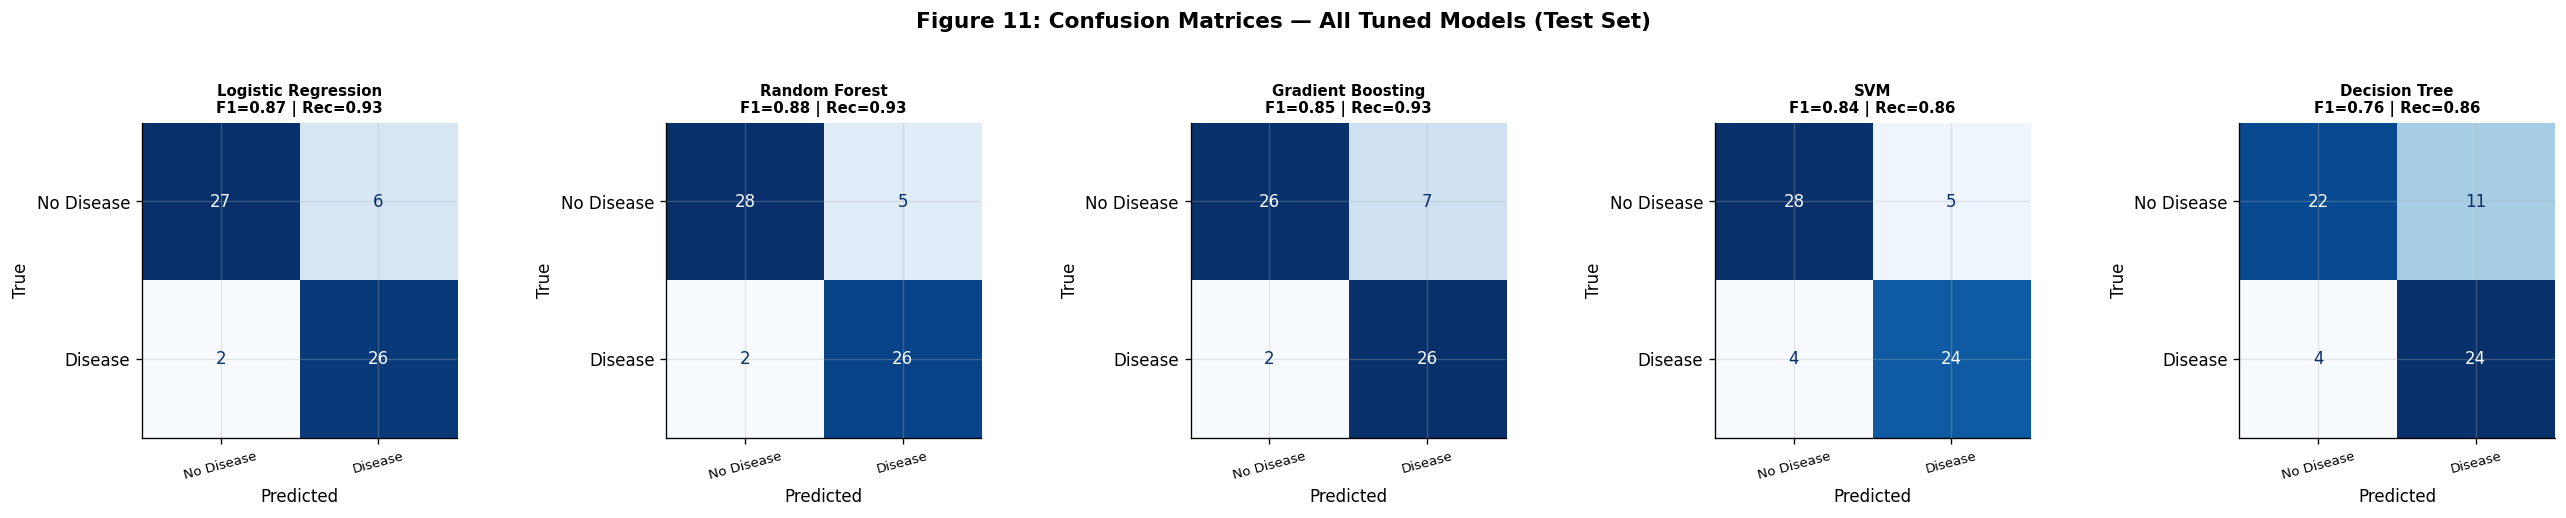

In [25]:
# Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred)
    ax.set_title(f'{name}\nF1={f1:.2f} | Rec={rec:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', labelsize=8, rotation=15)
plt.suptitle('Figure 11: Confusion Matrices — All Tuned Models (Test Set)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [26]:
# Final Model Selection Decision
tuned_cv = {}
for name, model in tuned_models.items():
    sc = cross_validate(model, X_train_scaled, y_train, cv=cv,
                         scoring=['f1', 'recall', 'roc_auc'], return_train_score=False)
    tuned_cv[name] = sc
scorecard = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    cv_f1_mean = tuned_cv[name]['test_f1'].mean()
    cv_f1_std  = tuned_cv[name]['test_f1'].std()
    scorecard.append({
        'Model': name,
        'Test F1': round(f1_score(y_test, y_pred), 3),
        'Test Recall': round(recall_score(y_test, y_pred), 3),
        'Test AUC': round(roc_auc_score(y_test, y_prob), 3),
        'CV F1 (mean)': round(cv_f1_mean, 3),
        'CV F1 (std)': round(cv_f1_std, 3),
        'Recall≥0.80': '' if recall_score(y_test, y_pred) >= 0.80 else ''
    })
scorecard_df = pd.DataFrame(scorecard).set_index('Model')
print(scorecard_df.to_string())
eligible = scorecard_df[scorecard_df['Recall≥0.80'] == '']
winner = eligible['Test F1'].idxmax()
print(f"\nSELECTED MODEL: {winner}")

                     Test F1  Test Recall  Test AUC  CV F1 (mean)  CV F1 (std) Recall≥0.80
Model                                                                                     
Logistic Regression    0.867        0.929     0.958         0.813        0.045            
Random Forest          0.881        0.929     0.957         0.804        0.010            
Gradient Boosting      0.852        0.929     0.956         0.804        0.024            
SVM                    0.842        0.857     0.934         0.804        0.045            
Decision Tree          0.762        0.857     0.817         0.685        0.069            

SELECTED MODEL: Random Forest


---
## Final Model — Deep Dive


In [27]:
# Final Model Detailed Report
final_model = tuned_models[winner]
y_pred_final = final_model.predict(X_test_scaled)
y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]
print(f"FINAL MODEL: {winner}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final,
                              target_names=['No Disease', 'Disease']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_final):.4f}")

FINAL MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

AUC-ROC: 0.9567


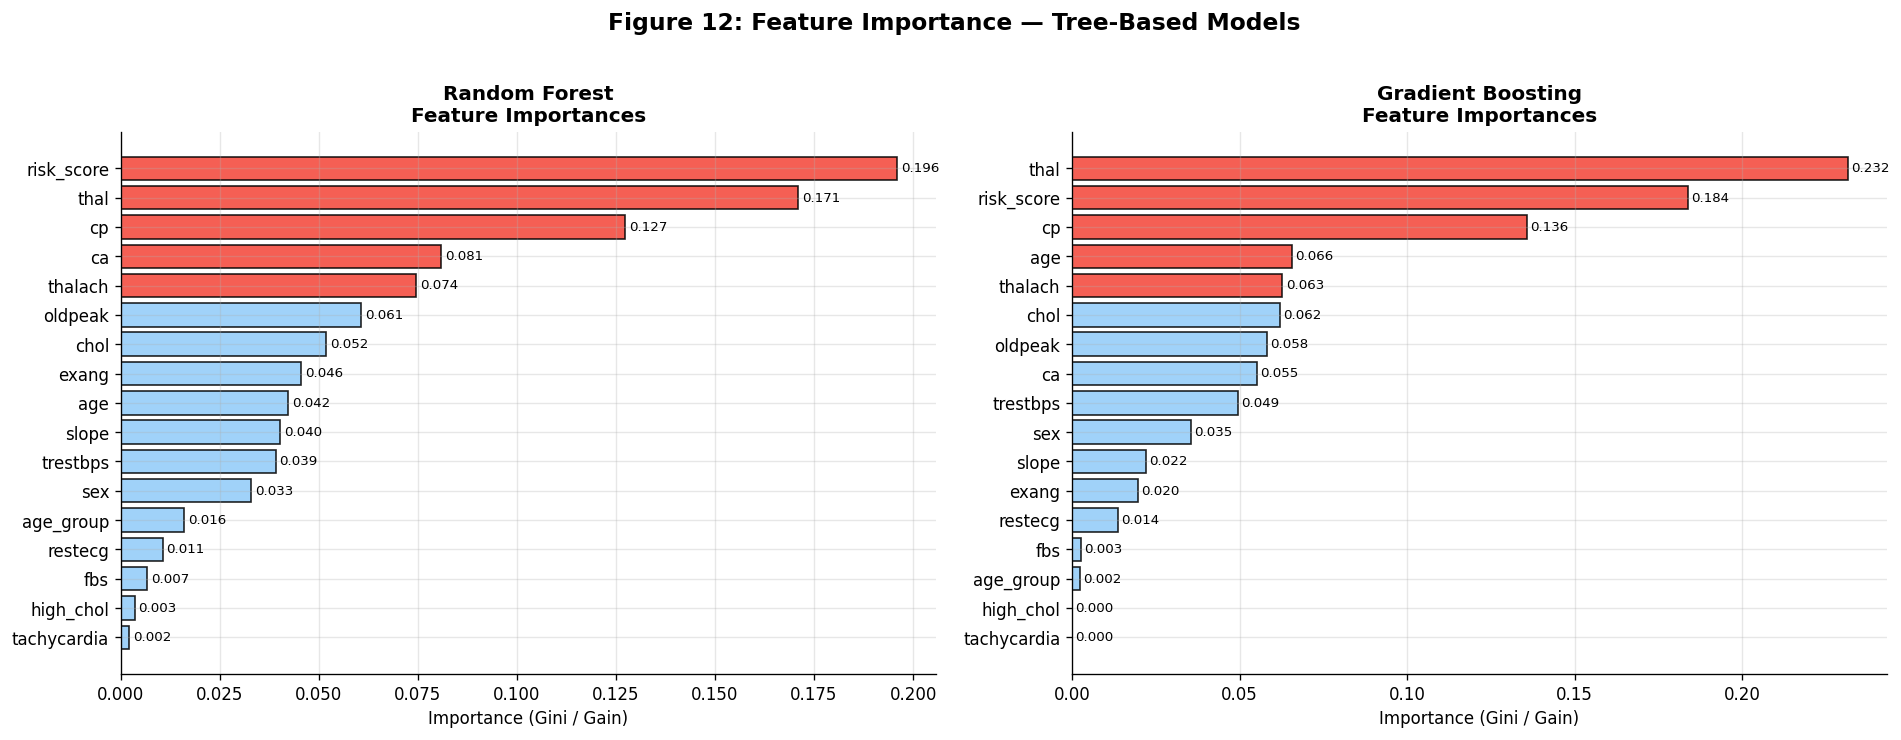

In [28]:
# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (model_name, model) in zip(axes, [
    ('Random Forest', tuned_models['Random Forest']),
    ('Gradient Boosting', tuned_models['Gradient Boosting'])
]):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
    colors_fi = ['#F44336' if v >= feat_imp.quantile(0.75) else '#90CAF9' for v in feat_imp.values]
    bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='black', alpha=0.85)
    ax.set_title(f'{model_name}\nFeature Importances', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance (Gini / Gain)')
    for bar, v in zip(bars, feat_imp.values):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('Figure 12: Feature Importance — Tree-Based Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

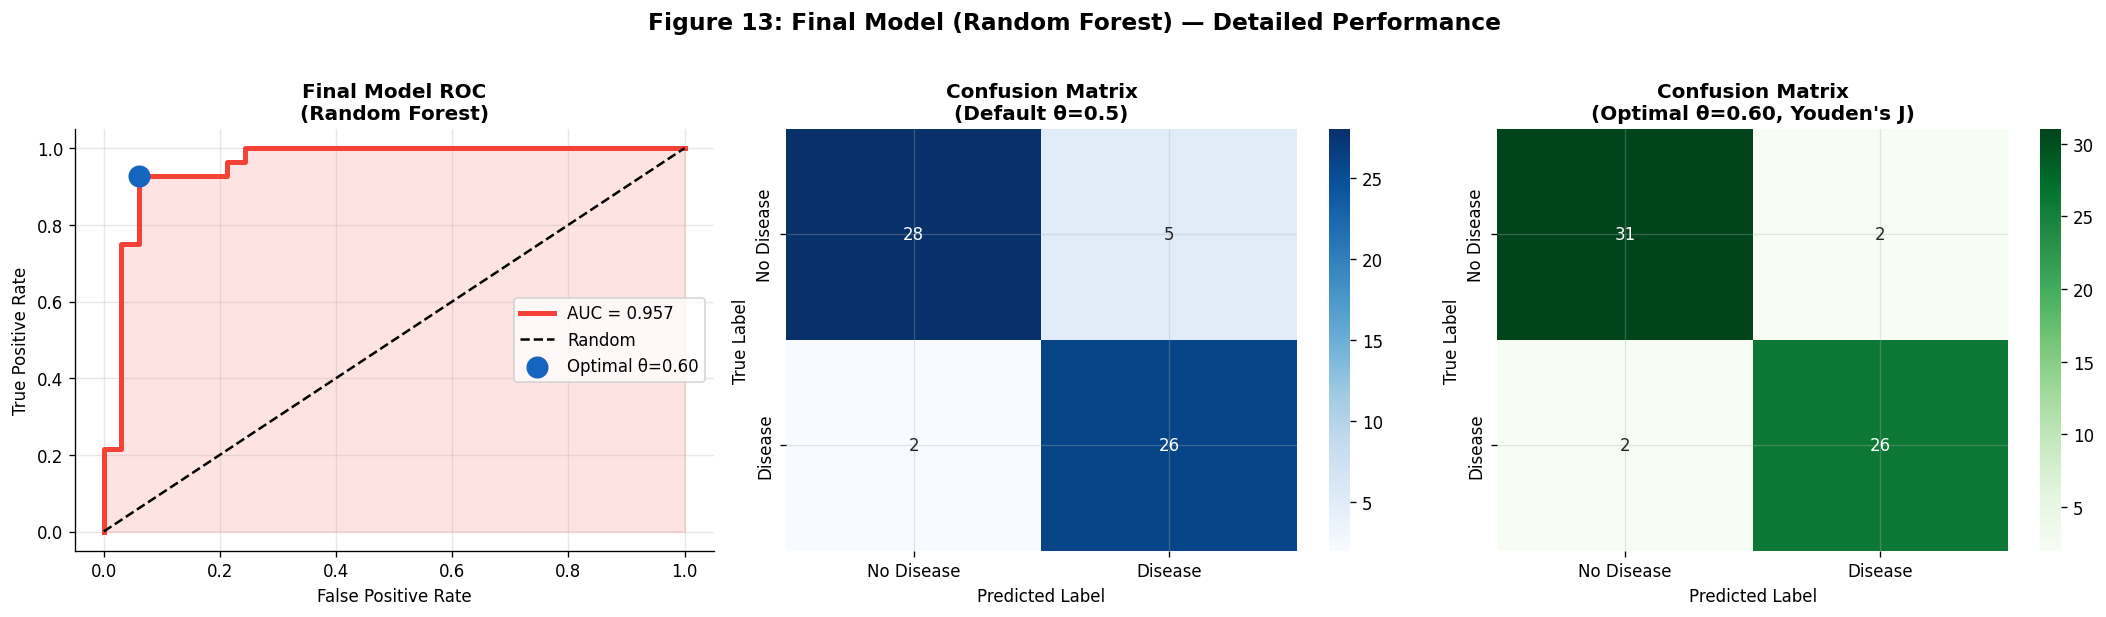


Performance with default threshold (0.5):
   Recall: 0.929

Performance with Youden optimal threshold (0.60):
   Recall: 0.929


In [29]:
# Final Model ROC + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
auc_val = roc_auc_score(y_test, y_prob_final)
axes[0].plot(fpr, tpr, color='#F44336', linewidth=3, label=f'AUC = {auc_val:.3f}')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#F44336')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Final Model ROC\n({winner})', fontweight='bold')
axes[0].legend()
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
opt_threshold = thresholds[opt_idx]
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=150, zorder=5,
                 color='#1565C0', label=f'Optimal θ={opt_threshold:.2f}')
axes[0].legend()
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
             xticklabels=['No Disease', 'Disease'],
             yticklabels=['No Disease', 'Disease'])
axes[1].set_title(f'Confusion Matrix\n(Default θ=0.5)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
y_pred_opt = (y_prob_final >= opt_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[2],
             xticklabels=['No Disease', 'Disease'],
             yticklabels=['No Disease', 'Disease'])
axes[2].set_title(f'Confusion Matrix\n(Optimal θ={opt_threshold:.2f}, Youden\'s J)', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')
plt.suptitle(f'Figure 13: Final Model ({winner}) — Detailed Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\nPerformance with default threshold (0.5):")
print(f"   Recall: {recall_score(y_test, y_pred_final):.3f}")
print(f"\nPerformance with Youden optimal threshold ({opt_threshold:.2f}):")
print(f"   Recall: {recall_score(y_test, y_pred_opt):.3f}")

In [30]:
# Model Serialisation for Deployment
import pickle
deploy_package = {
    'scaler': scaler,
    'model': final_model,
    'features': FEATURES,
    'model_name': winner,
    'optimal_threshold': float(opt_threshold)
}
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(deploy_package, f)